# 06: Int8 Attention + KV Cache

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d}}\right) V$$

Q, K, V are projections of the input: $Q = W_q x$, $K = W_k x$, $V = W_v x$.

The weight matrices $W_q, W_k, W_v$ are ternary (handled by TernaryLinear).
But the outputs Q, K, V are dense int8/float vectors. So $QK^T$ is not ternary.
Once you multiply $W_q \cdot x$, the result Q is a dense vector with values spread across the
full int8 range.

| operation | left | right | structure |
|:---|:---|:---|:---|
| $W_q \cdot x$ | ternary weights | int8 activations | TL1 vpshufb GEMM |
| $Q \cdot K^T$ | dense Q (int8) | dense K (int8) | standard int8 matmul |
| $\text{attn} \cdot V$ | dense attn (float) | dense V (float) | standard float matmul |

In [1]:
import pathlib
import sys

sys.path.insert(0, str(pathlib.Path("../")))

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

## Int8 QK^T

Quantize Q and K per-vector (per query token, per key token).
Scale = 127 / max(|x|). Each dot prod is rescaled:

$$\text{score}_{ij} = \frac{\text{int8\_dot}(Q_i, K_j)}{s_{Q_i} \cdot s_{K_j} \cdot \sqrt{d}}$$

In [2]:
# per-vector absmax quantize
def to_i8(x):
    scale = 127.0 / x.abs().amax(dim=-1, keepdim=True).clamp(min=1e-5)
    return (x * scale).round().clamp(-128, 127).to(torch.int8), scale


torch.manual_seed(0)
q = torch.randn(1, 128)  # one query, head_dim=12
k = torch.randn(512, 128)  # 512 cached keys

q_i8, q_s = to_i8(q)
k_i8, k_s = to_i8(k)

scores_int = q_i8.int() @ k_i8.int().T
scores_approx = scores_int.float() / (q_s * k_s.T) / (128**0.5)  # rescale to approx

# float ref
scores_ref = (q @ k.T) / (128**0.5)

print(f"max error:  {(scores_ref - scores_approx).abs().max():.4f}")
print(f"mean error: {(scores_ref - scores_approx).abs().mean():.4f}")

max error:  0.0370
mean error: 0.0080


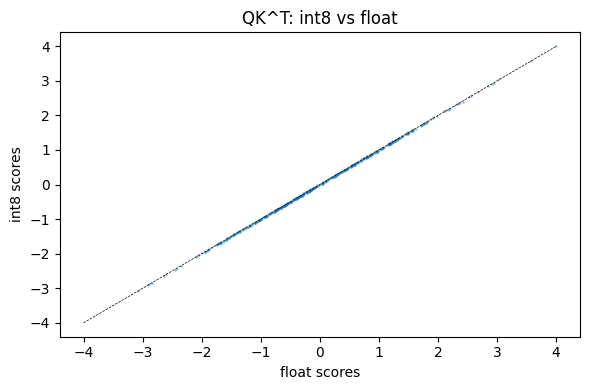

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(
    scores_ref.flatten().numpy(),
    scores_approx.flatten().numpy(),
    s=1,
    alpha=0.3,
)
lim = max(scores_ref.abs().max().item(), scores_approx.abs().max().item())
ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.5)
ax.set_xlabel("float scores")
ax.set_ylabel("int8 scores")
ax.set_title("QK^T: int8 vs float")
plt.tight_layout()
plt.show()

## C kernel: tiled int8 dot products

$QK^T$: dot(Q[i], K[j]) for all (i, j). Each is head_dim int8*int8 products, acc int32.

Without tiling: one k-loop per output element. For kv_len=2048, head_dim=128, that's
2048 separate loops of 8 SIMD iterations each, each ending with a scalar reduction.

With TILE_N=12: one k-loop computes 12 outputs at once. Same Q chunk loaded once,
applied to 12 different K rows. 12 scalar reductions at the end instead of one per loop:

```
for each tile of 12 K rows:
    acc[0..11] = 0
    for d in 0..head_dim step 16:
        va = sign_extend(Q[d:d+16])       # one load, reused 12x
        
        for t in 0..11:
            vb = sign_extend(K[j+t][d:d+16])
            acc[t] += madd_epi16(va, vb)   # 16 int16 pairs -> 8 int32
            
    scores[j..j+12] = hsum(acc[0..11])     # 12 reductions per tile
```

Decode (m=1): OpenMP over j-tiles (170+ for kv=2048).
Prefill (m>1): OpenMP over query rows.

| instruction | what it does |
|:---|:---|
| `_mm256_cvtepi8_epi16` | sign-extend 16 int8 to 16 int16 |
| `_mm256_madd_epi16` | multiply 16 int16 pairs, pairwise sum into 8 int32 |
| `_mm_shuffle_epi32` + `_mm_add_epi32` | reduce 4 int32 lanes to scalar |

## Benchmark: int8 vs float

In [4]:
import time

from smelt._clib import load_lib

lib = load_lib()

configs = [
    ("decode hd=128 kv=512", 1, 512, 128),
    ("decode hd=128 kv=2048", 1, 2048, 128),
    ("decode hd=64 kv=2048", 1, 2048, 64),
    ("prefill 64 hd=128", 64, 64, 128),
]

results = []
for label, m, n, k in configs:
    a = torch.randint(-128, 127, (m, k), dtype=torch.int8)
    b = torch.randint(-128, 127, (n, k), dtype=torch.int8)
    af, bf = a.float(), b.float()

    lib.int8_gemm_t(a, b)
    t0 = time.perf_counter()
    for _ in range(500):
        lib.int8_gemm_t(a, b)
    t_int = (time.perf_counter() - t0) / 500 * 1e6

    af @ bf.T
    t0 = time.perf_counter()
    for _ in range(500):
        af @ bf.T
    t_float = (time.perf_counter() - t0) / 500 * 1e6

    results.append({"name": label, "int8": t_int, "float": t_float})
    ratio = t_float / t_int
    tag = f"{ratio:.1f}x faster" if ratio > 1 else f"{1 / ratio:.1f}x slower"
    print(f"  {label:>30s}:  int8={t_int:6.0f}us  float={t_float:6.0f}us  {tag}")

            decode hd=128 kv=512:  int8=     4us  float=     8us  2.1x faster
           decode hd=128 kv=2048:  int8=     6us  float=    12us  2.0x faster
            decode hd=64 kv=2048:  int8=     7us  float=     9us  1.4x faster
               prefill 64 hd=128:  int8=     8us  float=    14us  1.7x faster


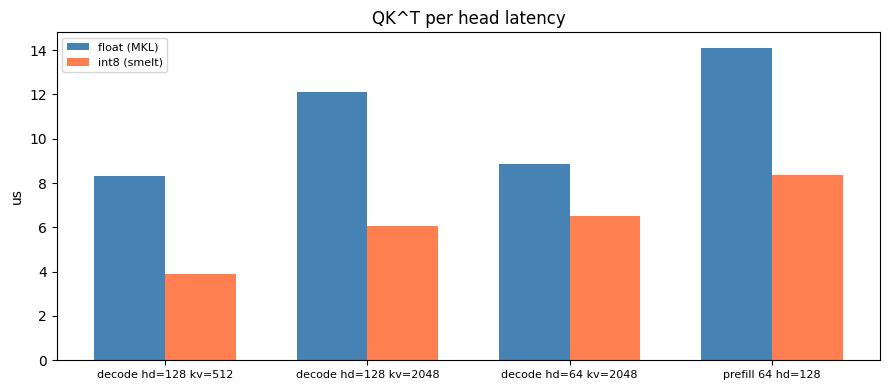

In [5]:
names = [r["name"] for r in results]
x_pos = np.arange(len(names))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x_pos - w / 2, [r["float"] for r in results], w, label="float (MKL)", color="steelblue")
ax.bar(x_pos + w / 2, [r["int8"] for r in results], w, label="int8 (smelt)", color="coral")
ax.set_xticks(x_pos)
ax.set_xticklabels(names, fontsize=8)
ax.set_ylabel("us")
ax.legend(fontsize=8)
ax.set_title("QK^T per head latency")
plt.tight_layout()
plt.show()

## KV cache

Autoregressive rollout: each new token attends to all previous tokens.
Without caching, recomputing K and V for all past tokens every step is O(n^2).

KV cache: store K, V projections as they're computed. Each decode step
appends one new K, V pair and reads the full cache for attention.

```
prefill (prompt):  compute K, V for all tokens, store in cache
decode (step t):   compute K_t, V_t for new token, append to cache
                   Q_t attends to cache[:t] via QK^T + softmax + attn*V
```

Pre-allocated buffer avoids per-step allocation. Position counter tracks fill level.

In [6]:
from smelt.attention import Attention, KVCache
from smelt.rope import precompute_freqs_float

torch.manual_seed(0)
dim, n_heads, hd = 64, 4, 16

attn = Attention(
    q_proj=nn.Linear(dim, dim, bias=False),
    k_proj=nn.Linear(dim, dim, bias=False),
    v_proj=nn.Linear(dim, dim, bias=False),
    o_proj=nn.Linear(dim, dim, bias=False),
    n_heads=n_heads,
)

cos, sin = precompute_freqs_float(hd, 64)
freqs = (cos, sin)

x = torch.randn(1, 10, dim)

# forward (no cache)
y_ref = attn(x, freqs=freqs)

# prefill + decode
cache = KVCache(64, n_heads, hd)
y_pre = attn(x[:, :8], freqs=freqs, cache=cache)
y_d8 = attn(x[:, 8:9], freqs=freqs, cache=cache)
y_d9 = attn(x[:, 9:10], freqs=freqs, cache=cache)

print(f"prefill matches:  {torch.allclose(y_ref[:, :8], y_pre, atol=1e-4)}")
print(f"decode t=8 match: {torch.allclose(y_ref[:, 8:9], y_d8, atol=1e-4)}")
print(f"decode t=9 match: {torch.allclose(y_ref[:, 9:10], y_d9, atol=1e-4)}")
print(f"cache position:   {cache.pos}")

prefill matches:  True
decode t=8 match: True
decode t=9 match: True
cache position:   10


## GQA (Grouped Query Attention)

Standard MHA: equal number of Q, K, V heads. KV cache scales with n_heads.

GQA: fewer KV heads than Q heads. Multiple Q heads share one KV head.
Before the matmul, each KV head is repeated to match the Q head count
(just a broadcast, no new parameters or computation).

| model | n_heads | n_kv_heads | ratio |
|:---|---:|---:|---:|
| Llama 2 7B | 32 | 32 | 1:1 (MHA) |
| Llama 2 70B | 64 | 8 | 8:1 (GQA) |
| Llama 3 8B | 32 | 8 | 4:1 (GQA) |
| Mistral 7B | 32 | 8 | 4:1 (GQA) |

In [7]:
torch.manual_seed(0)
attn_gqa = Attention(
    q_proj=nn.Linear(dim, dim, bias=False),
    k_proj=nn.Linear(dim, n_heads // 2 * hd, bias=False),
    v_proj=nn.Linear(dim, n_heads // 2 * hd, bias=False),
    o_proj=nn.Linear(dim, dim, bias=False),
    n_heads=n_heads,
    n_kv_heads=n_heads // 2,
)

x = torch.randn(1, 8, dim)
y = attn_gqa(x, freqs=freqs)
print(f"GQA output shape: {y.shape}")
print(f"Q heads: {n_heads}, KV heads: {n_heads // 2}")
print(f"KV cache savings: {n_heads // (n_heads // 2)}x")

GQA output shape: torch.Size([1, 8, 64])
Q heads: 4, KV heads: 2
KV cache savings: 2x
